In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches = pd.read_csv("matches_clean.csv")

In [ ]:
print(matches["stage"].unique())

['League' 'Qualifier 1' 'Eliminator' 'Qualifier 2' 'Final']


In [ ]:
pressure_matches = matches[
    matches["stage"] != "League"
].copy()

pressure_matches.head()

,match_id,season,match_number,stage,date,venue,city,team1,team2,toss_winner,...,result,winner,win_by,win_margin,player_of_match,umpire1,umpire2,is_day_night,match_total_runs,match_status
56,M0057,2008,57,Qualifier 1,2008-05-26,Brabourne Stadium,Mumbai,Royal Challengers Bengaluru,Punjab Kings,Royal Challengers Bengaluru,...,normal,Punjab Kings,runs,64,Mitchell Rizwan,CK Nandan,Richard Kettleborough,True,423,Completed
57,M0058,2008,58,Eliminator,2008-05-27,M. A. Chidambaram Stadium,Chennai,Chennai Super Kings,Delhi Capitals,Delhi Capitals,...,normal,Delhi Capitals,wickets,5,Dawid Iyer,KN Ananthapadmanabhan,Richard Kettleborough,False,332,Completed
58,M0059,2008,59,Qualifier 2,2008-05-29,Rajiv Gandhi Intl Cricket Stadium,Hyderabad,Deccan Chargers,Chennai Super Kings,Deccan Chargers,...,normal,Chennai Super Kings,runs,60,Shadab van der Dussen,Anil Chaudhary,AK Chaudhary,True,307,Completed
59,M0060,2008,60,Final,2008-05-31,Rajiv Gandhi Intl Cricket Stadium,Hyderabad,Delhi Capitals,Royal Challengers Bengaluru,Delhi Capitals,...,normal,Royal Challengers Bengaluru,runs,22,Harry Brook,Aleem Dar,Ulhas Gandhe,True,348,Completed
116,M0117,2009,57,Qualifier 1,2009-05-24,Barabati Stadium,Cuttack,Royal Challengers Bengaluru,Deccan Chargers,Deccan Chargers,...,normal,Royal Challengers Bengaluru,wickets,3,Shaheen Cummins,Rod Tucker,KN Ananthapadmanabhan,True,251,Completed


In [ ]:
pressure_played = pd.concat([
    pressure_matches[["match_id", "team1"]]
    .rename(columns={"team1":"team"}),

    pressure_matches[["match_id", "team2"]]
    .rename(columns={"team2":"team"})
])

pressure_played = (
    pressure_played.groupby("team")
    .size()
    .reset_index(name="pressure_matches")
)

pressure_played.head()

,team,pressure_matches
0,Chennai Super Kings,16
1,Deccan Chargers,6
2,Delhi Capitals,14
3,Gujarat Lions,1
4,Gujarat Titans,2


In [ ]:
pressure_wins = (
    pressure_matches.groupby("winner")
    .size()
    .reset_index(name="pressure_wins")
    .rename(columns={"winner":"team"})
)

pressure_wins.head()

,team,pressure_wins
0,Chennai Super Kings,9
1,Deccan Chargers,1
2,Delhi Capitals,5
3,Gujarat Titans,1
4,Kolkata Knight Riders,13


In [ ]:
pressure_stats = pressure_played.merge(
    pressure_wins,
    on="team",
    how="left"
)

pressure_stats["pressure_wins"] = (
    pressure_stats["pressure_wins"]
    .fillna(0)
)

In [ ]:
pressure_stats["pressure_win_pct"] = round(
    (
        pressure_stats["pressure_wins"]
        /
        pressure_stats["pressure_matches"]
    ) * 100,
    2
)

pressure_stats.head()

,team,pressure_matches,pressure_wins,pressure_win_pct
0,Chennai Super Kings,16,9.0,56.25
1,Deccan Chargers,6,1.0,16.67
2,Delhi Capitals,14,5.0,35.71
3,Gujarat Lions,1,0.0,0.00
4,Gujarat Titans,2,1.0,50.00


In [ ]:
verified_titles = pd.DataFrame({
    "team": [
        "Chennai Super Kings",
        "Mumbai Indians",
        "Kolkata Knight Riders",
        "Rajasthan Royals",
        "Sunrisers Hyderabad",
        "Gujarat Titans",
        "Deccan Chargers"
    ],
    "final_wins": [
        5,
        5,
        3,
        1,
        1,
        1,
        1
    ]
})

pressure_stats = pressure_stats.merge(
    verified_titles,
    on="team",
    how="left"
)

pressure_stats["final_wins"] = (
    pressure_stats["final_wins"]
    .fillna(0)
)

In [ ]:
print(pressure_stats.columns.tolist())

['team', 'pressure_matches', 'pressure_wins', 'pressure_win_pct', 'final_wins_x', 'pressure_score', 'final_wins_y', 'final_wins']


In [ ]:
pressure_stats["pressure_score"] = round(
    (
        pressure_stats["pressure_win_pct"] * 0.7
        +
        pressure_stats["final_wins"] * 5
    ),
    2
)

In [ ]:
pressure_stats["pressure_score"] = round(
    (
        pressure_stats["pressure_win_pct"] * 0.5
        +
        pressure_stats["final_wins"] * 10
    ),
    2
)

In [ ]:
pressure_rankings = pressure_stats.sort_values(
    "pressure_score",
    ascending=False
)

pressure_rankings.reset_index(
    drop=True,
    inplace=True
)

pressure_rankings.insert(
    0,
    "rank",
    range(1, len(pressure_rankings) + 1)
)

pressure_rankings.head(10)

,rank,team,pressure_matches,pressure_wins,pressure_win_pct,final_wins_x,pressure_score,final_wins_y,final_wins
0,1,Chennai Super Kings,16,9.0,56.25,5.0,78.12,5.0,5.0
1,2,Mumbai Indians,19,8.0,42.11,5.0,71.06,5.0,5.0
2,3,Kolkata Knight Riders,18,13.0,72.22,3.0,66.11,3.0,3.0
3,4,Sunrisers Hyderabad,11,6.0,54.55,1.0,37.28,1.0,1.0
4,5,Rajasthan Royals,19,10.0,52.63,1.0,36.32,1.0,1.0
5,6,Gujarat Titans,2,1.0,50.00,1.0,35.00,1.0,1.0
6,7,Pune Warriors India,3,2.0,66.67,0.0,33.34,NaN,0.0
7,8,Royal Challengers Bengaluru,21,10.0,47.62,0.0,23.81,NaN,0.0
8,9,Punjab Kings,11,5.0,45.45,0.0,22.72,NaN,0.0
9,10,Deccan Chargers,6,1.0,16.67,1.0,18.34,1.0,1.0


In [ ]:
pressure_rankings = pressure_stats.sort_values(
    "pressure_score",
    ascending=False
)

pressure_rankings.reset_index(
    drop=True,
    inplace=True
)

pressure_rankings.head(10)

,team,pressure_matches,pressure_wins,pressure_win_pct,final_wins_x,pressure_score,final_wins_y,final_wins
0,Chennai Super Kings,16,9.0,56.25,5.0,78.12,5.0,5.0
1,Mumbai Indians,19,8.0,42.11,5.0,71.06,5.0,5.0
2,Kolkata Knight Riders,18,13.0,72.22,3.0,66.11,3.0,3.0
3,Sunrisers Hyderabad,11,6.0,54.55,1.0,37.28,1.0,1.0
4,Rajasthan Royals,19,10.0,52.63,1.0,36.32,1.0,1.0
5,Gujarat Titans,2,1.0,50.00,1.0,35.00,1.0,1.0
6,Pune Warriors India,3,2.0,66.67,0.0,33.34,NaN,0.0
7,Royal Challengers Bengaluru,21,10.0,47.62,0.0,23.81,NaN,0.0
8,Punjab Kings,11,5.0,45.45,0.0,22.72,NaN,0.0
9,Deccan Chargers,6,1.0,16.67,1.0,18.34,1.0,1.0


In [ ]:
TEAM_COLORS = {
    "Chennai Super Kings": "#FFFF00",
    "Mumbai Indians": "#004BA0",
    "Royal Challengers Bangalore": "#EC1C24",
    "Royal Challengers Bengaluru": "#EC1C24",
    "Kolkata Knight Riders": "#3A225D",
    "Sunrisers Hyderabad": "#FF822A",
    "Delhi Capitals": "#17449B",
    "Delhi Daredevils": "#17449B",
    "Rajasthan Royals": "#FF69B4",
    "Kings XI Punjab": "#D71920",
    "Punjab Kings": "#D71920",
    "Gujarat Titans": "#1B2133",
    "Lucknow Super Giants": "#00AEEF",
    "Deccan Chargers": "#1E88E5",
    "Pune Warriors India": "#5E35B1"
}

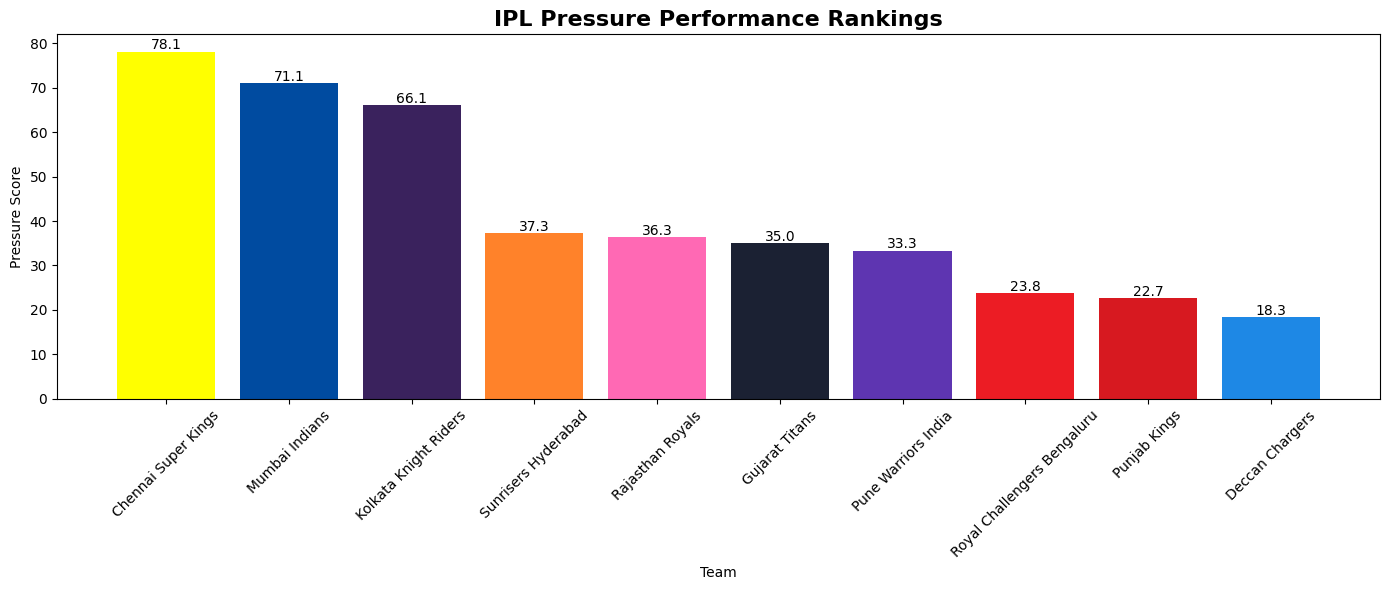

In [ ]:
import matplotlib.pyplot as plt

top10 = pressure_rankings.head(10)

colors = [
    TEAM_COLORS.get(team, "#808080")
    for team in top10["team"]
]

plt.figure(figsize=(14,6))

bars = plt.bar(
    top10["team"],
    top10["pressure_score"],
    color=colors
)

plt.title(
    "IPL Pressure Performance Rankings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Team")
plt.ylabel("Pressure Score")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
pressure_rankings = pressure_rankings[
    [
        "team",
        "pressure_matches",
        "pressure_wins",
        "pressure_win_pct",
        "final_wins",
        "pressure_score"
    ]
]

pressure_rankings.head(10)

,team,pressure_matches,pressure_wins,pressure_win_pct,final_wins,pressure_score
0,Chennai Super Kings,16,9.0,56.25,5.0,78.12
1,Mumbai Indians,19,8.0,42.11,5.0,71.06
2,Kolkata Knight Riders,18,13.0,72.22,3.0,66.11
3,Sunrisers Hyderabad,11,6.0,54.55,1.0,37.28
4,Rajasthan Royals,19,10.0,52.63,1.0,36.32
5,Gujarat Titans,2,1.0,50.00,1.0,35.00
6,Pune Warriors India,3,2.0,66.67,0.0,33.34
7,Royal Challengers Bengaluru,21,10.0,47.62,0.0,23.81
8,Punjab Kings,11,5.0,45.45,0.0,22.72
9,Deccan Chargers,6,1.0,16.67,1.0,18.34


In [ ]:
pressure_rankings.to_csv(
    "pressure_performance_rankings.csv",
    index=False
)

In [ ]:
pressure_rankings.head(10)

,team,pressure_matches,pressure_wins,pressure_win_pct,final_wins,pressure_score
0,Chennai Super Kings,16,9.0,56.25,5.0,78.12
1,Mumbai Indians,19,8.0,42.11,5.0,71.06
2,Kolkata Knight Riders,18,13.0,72.22,3.0,66.11
3,Sunrisers Hyderabad,11,6.0,54.55,1.0,37.28
4,Rajasthan Royals,19,10.0,52.63,1.0,36.32
5,Gujarat Titans,2,1.0,50.00,1.0,35.00
6,Pune Warriors India,3,2.0,66.67,0.0,33.34
7,Royal Challengers Bengaluru,21,10.0,47.62,0.0,23.81
8,Punjab Kings,11,5.0,45.45,0.0,22.72
9,Deccan Chargers,6,1.0,16.67,1.0,18.34
